<a href="https://colab.research.google.com/github/Melckykaisha/Movie_recommender_system/blob/main/Digital_Image_processing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Image Processing Lab 1:Sharpening and Restoration for Images


## Environment Setup & Library Installation

In [ ]:
# Install required libraries
!pip install opencv-python numpy matplotlib scikit-image --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import warnings
warnings.filterwarnings('ignore')

print('OpenCV version:', cv2.__version__)
print('NumPy version:', np.__version__)
print('All libraries ready for DIP Lab 1!')

OpenCV version: 4.13.0
NumPy version: 2.0.2
All libraries ready for DIP Lab 1!


---
# EXERCISE 1: Load, Blur, Sharpen, and Compare

### Step 1: Load Image and Examine Properties

In [ ]:
# Load built-in test image
original = data.camera()

print('*** IMAGE PROPERTIES *** ')
print(f'Shape: {original.shape}')
print(f'Data type: {original.dtype}')
print(f'Value range: [{original.min()}, {original.max()}]')



*** IMAGE PROPERTIES *** 
Shape: (512, 512)
Data type: uint8
Value range: [0, 255]


### Step 2: Apply Gaussian Blur

In [ ]:
# Apply Gaussian blur with kernel size (5,5) and sigma=2
blurred = cv2.GaussianBlur(original, (5, 5), sigmaX=2)

print('*** BLURRED IMAGE ***')
print(f'Shape: {blurred.shape}')
print(f'Value range: [{blurred.min()}, {blurred.max()}]')

*** BLURRED IMAGE ***
Shape: (512, 512)
Value range: [3, 254]


### Step 3: Apply Laplacian Sharpening Filter

In [1]:
# Define Laplacian kernel
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

print('*** LAPLACIAN KERNEL ***')
print(kernel)
print(f'Kernel sum: {kernel.sum()} (flat regions contribute 0)')

# Apply filter
laplacian = cv2.filter2D(blurred.astype(np.float32), ddepth=-1, kernel=kernel)

# Add back to blurred image
sharpened_float = blurred.astype(np.float32) + laplacian

# Clip to valid range and convert to uint8
sharpened = np.clip(sharpened_float, 0, 255).astype(np.uint8)

print('\n*** AFTER SHARPENING ***')
print(f'Value range: [{sharpened.min()}, {sharpened.max()}]')

NameError: name 'np' is not defined

### Step 4: Finding the  Difference of Image

In [ ]:
# Compute difference between sharpened and original
diff = sharpened.astype(np.float32) - original.astype(np.float32)

# Rescale for display (shift to center at grey)
diff_display = np.clip(diff + 128, 0, 255).astype(np.uint8)

print('*** DIFFERENCE OF THE IMAGE ***')
print(f'Original range: [{diff.min():.2f}, {diff.max():.2f}]')
print(f'After rescaling: [{diff_display.min()}, {diff_display.max()}]')
print('Bright areas = regions where sharpening added brightness (edges)')

*** DIFFERENCE OF THE IMAGE ***
Original range: [-188.00, 139.00]
After rescaling: [0, 255]
Bright areas = regions where sharpening added brightness (edges)


### Step 5: Display All Four Images in a 2x2 Grid

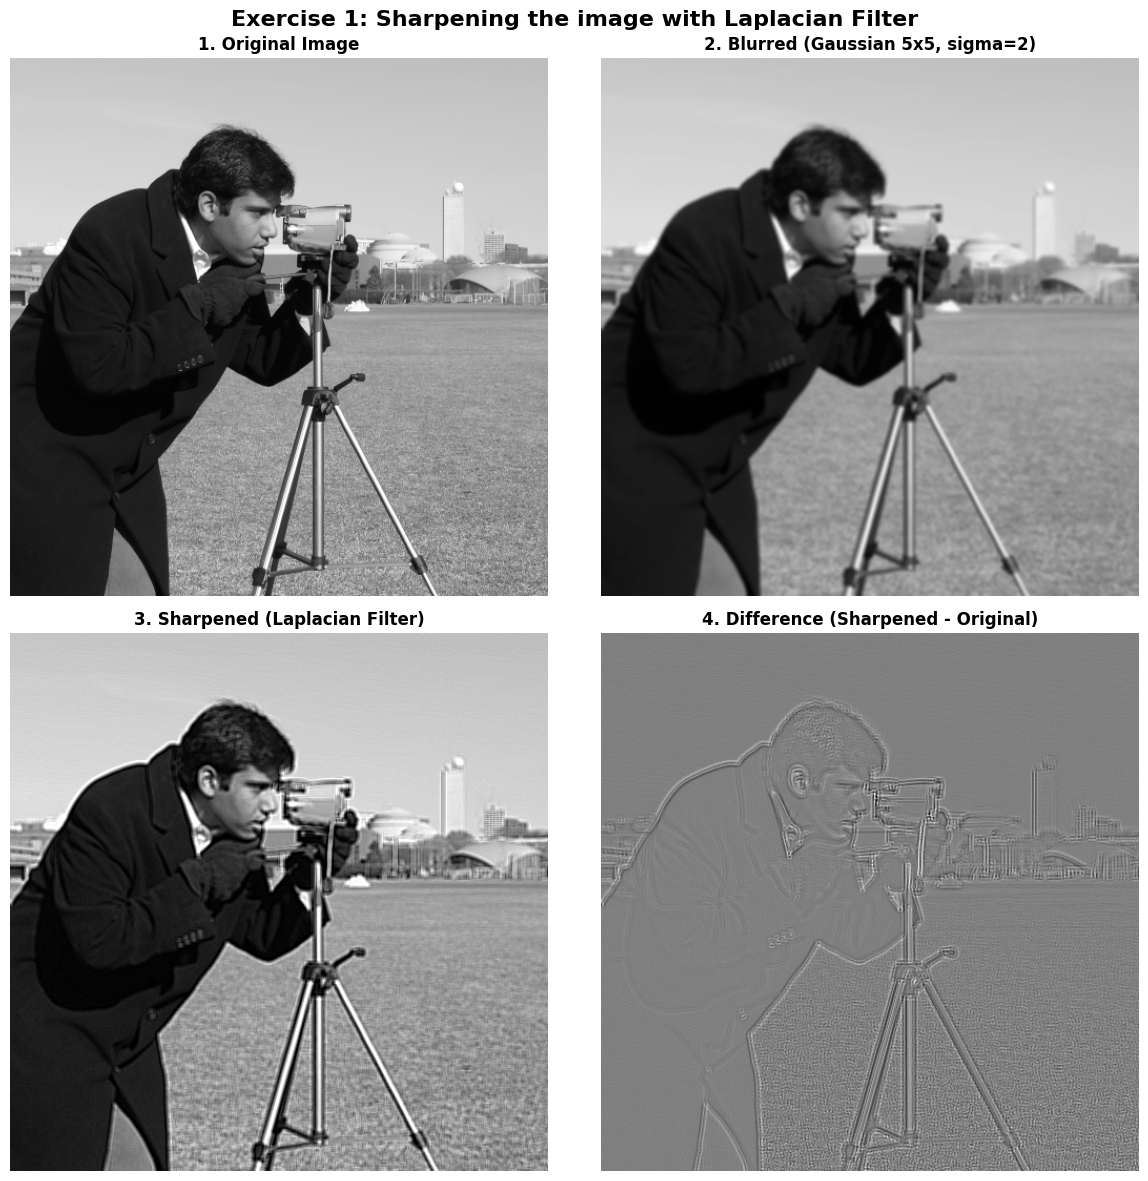

 Figure saved as image_output_exercise1.png


In [ ]:
# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Exercise 1: Sharpening the image with Laplacian Filter',
             fontsize=16, fontweight='bold')

# Panel 1: Original
axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('1. Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Panel 2: Blurred
axes[0, 1].imshow(blurred, cmap='gray')
axes[0, 1].set_title('2. Blurred (Gaussian 5x5, sigma=2)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Panel 3: Sharpened
axes[1, 0].imshow(sharpened, cmap='gray')
axes[1, 0].set_title('3. Sharpened (Laplacian Filter)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Panel 4: Difference
axes[1, 1].imshow(diff_display, cmap='gray')
axes[1, 1].set_title('4. Difference (Sharpened - Original)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('image_output_exercise1 .png', dpi=150, bbox_inches='tight')
plt.show()

print(' Figure saved as image_output_exercise1.png')

---
# EXERCISE 2: Noise Addition and Median Filtering

### Step 1: Load Coins Image

**** COINS IMAGE ****
Shape: (303, 384)
Value range: [1, 252]


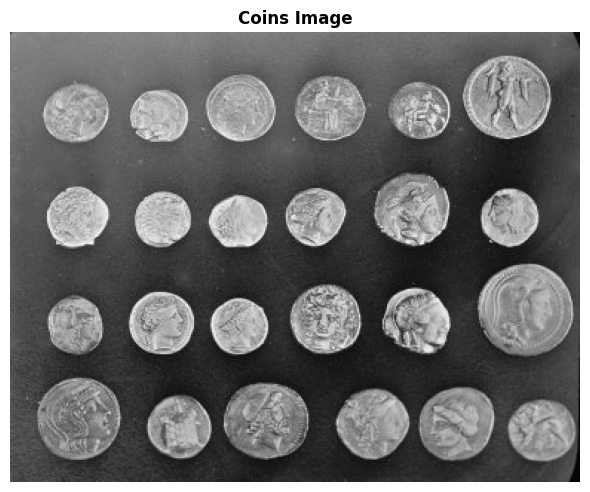

In [ ]:
# Load different test image
original_ex2 = data.coins()

print('**** COINS IMAGE ****')
print(f'Shape: {original_ex2.shape}')
print(f'Value range: [{original_ex2.min()}, {original_ex2.max()}]')

plt.figure(figsize=(6, 6))
plt.imshow(original_ex2, cmap='gray')
plt.title('Coins Image', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 2: Add Salt-and-Pepper Noise

**** NOISE ADDITION ****
Noise level: 5%
Total pixels: 116,352
Corrupted pixels: ~5,817


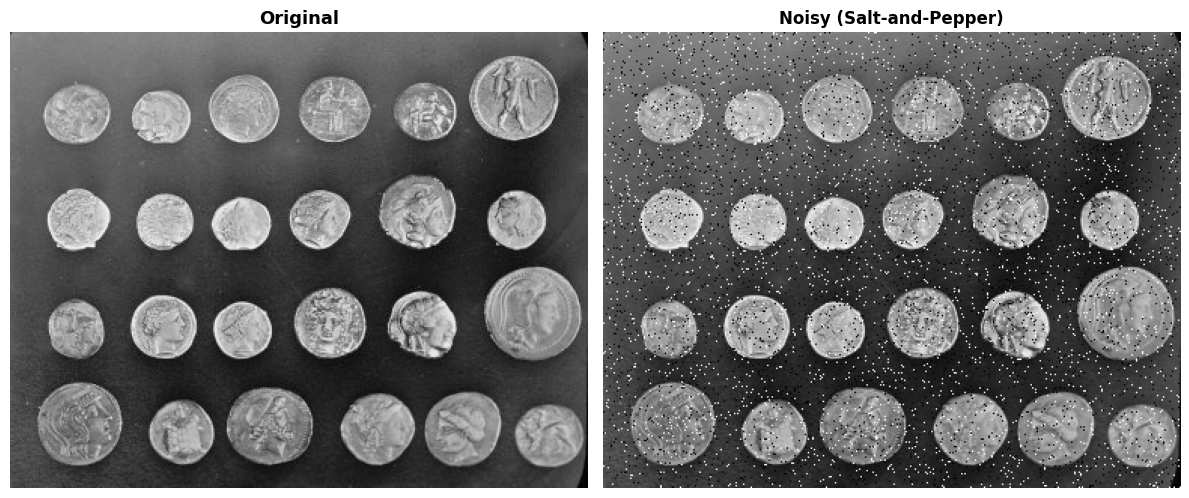

In [ ]:
def add_salt_pepper(image, noise_level=0.05):
    """Add salt-and-pepper noise to image."""
    noisy = image.copy()
    total_pixels = image.size
    n_corrupt = int(total_pixels * noise_level)

    # Add salt (white pixels)
    salt_coords = [np.random.randint(0, i, n_corrupt // 2) for i in image.shape]
    noisy[salt_coords[0], salt_coords[1]] = 255

    # Add pepper (black pixels)
    pepper_coords = [np.random.randint(0, i, n_corrupt // 2) for i in image.shape]
    noisy[pepper_coords[0], pepper_coords[1]] = 0

    return noisy

# Apply noise
np.random.seed(42)
noisy_ex2 = add_salt_pepper(original_ex2, noise_level=0.05)

n_corrupted = int(original_ex2.size * 0.05)
print('**** NOISE ADDITION ****')
print(f'Noise level: 5%')
print(f'Total pixels: {original_ex2.size:,}')
print(f'Corrupted pixels: ~{n_corrupted:,}')

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_ex2, cmap='gray')
axes[0].set_title('Original', fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(noisy_ex2, cmap='gray')
axes[1].set_title('Noisy (Salt-and-Pepper)', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Step 3: Apply Median Filter and Gaussian Blur

In [ ]:
# Median filter (excellent for salt-and-pepper)
denoised_median = cv2.medianBlur(noisy_ex2, ksize=3)

print('**** MEDIAN FILTER ****')
print('Kernel size: 3x3')
print('Why it works: Sorts pixels, takes median (outliers ignored)')

# Gaussian blur for comparison (wrong tool for this job)
denoised_gaussian = cv2.GaussianBlur(noisy_ex2, (3, 3), sigmaX=1)

print('\n**** GAUSSIAN BLUR (FOR COMPARISON) ****')
print('Why it is NOT ideal: Takes average, spreading outliers')

**** MEDIAN FILTER ****
Kernel size: 3x3
Why it works: Sorts pixels, takes median (outliers ignored)

**** GAUSSIAN BLUR (FOR COMPARISON) ****
Why it is NOT ideal: Takes average, spreading outliers


### Step 4: Compare Methods

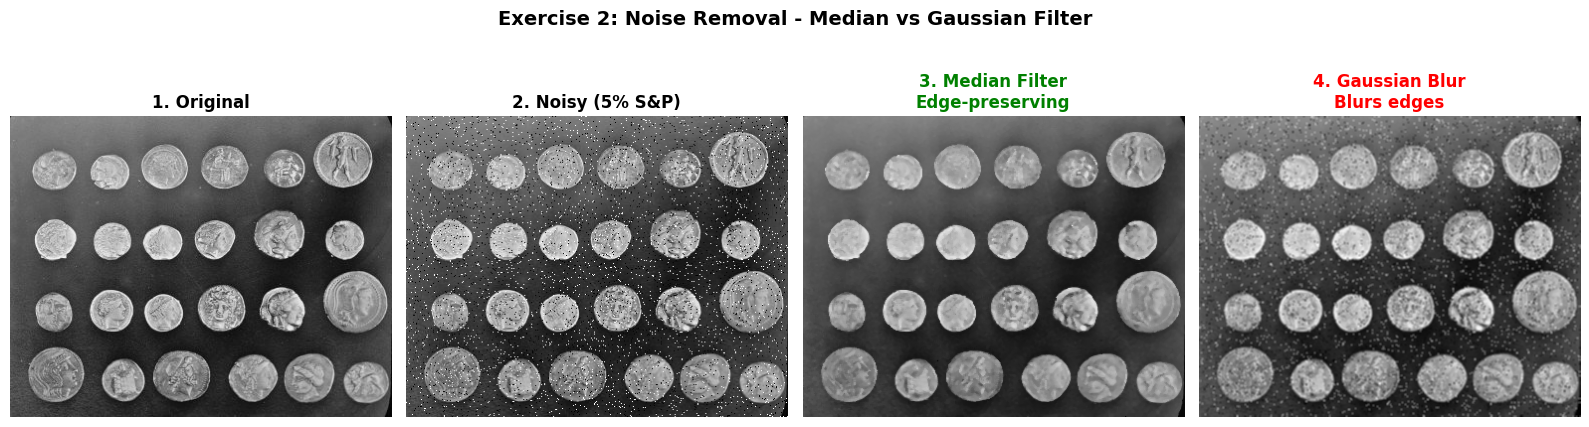

✓ Figure saved as image_output_exersice2.png


In [ ]:
# Create comparison figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Exercise 2: Noise Removal - Median vs Gaussian Filter',
             fontsize=14, fontweight='bold')

axes[0].imshow(original_ex2, cmap='gray')
axes[0].set_title('1. Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(noisy_ex2, cmap='gray')
axes[1].set_title('2. Noisy (5% S&P)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(denoised_median, cmap='gray')
axes[2].set_title('3. Median Filter\nEdge-preserving', fontsize=12, fontweight='bold', color='green')
axes[2].axis('off')

axes[3].imshow(denoised_gaussian, cmap='gray')
axes[3].set_title('4. Gaussian Blur\nBlurs edges', fontsize=12, fontweight='bold', color='red')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('image_output_exersice2.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Figure saved as image_output_exersice2.png')

---
# EXERCISE 3: The Full Restoration Pipeline

### Step 1: Simulate Image Degradation

**** DEGRADATION PIPELINE ****
Step 1: Add noise (3% salt-and-pepper)
Step 2: Add blur (Gaussian 5x5, sigma=1.5)
Degraded image range: [3, 254]


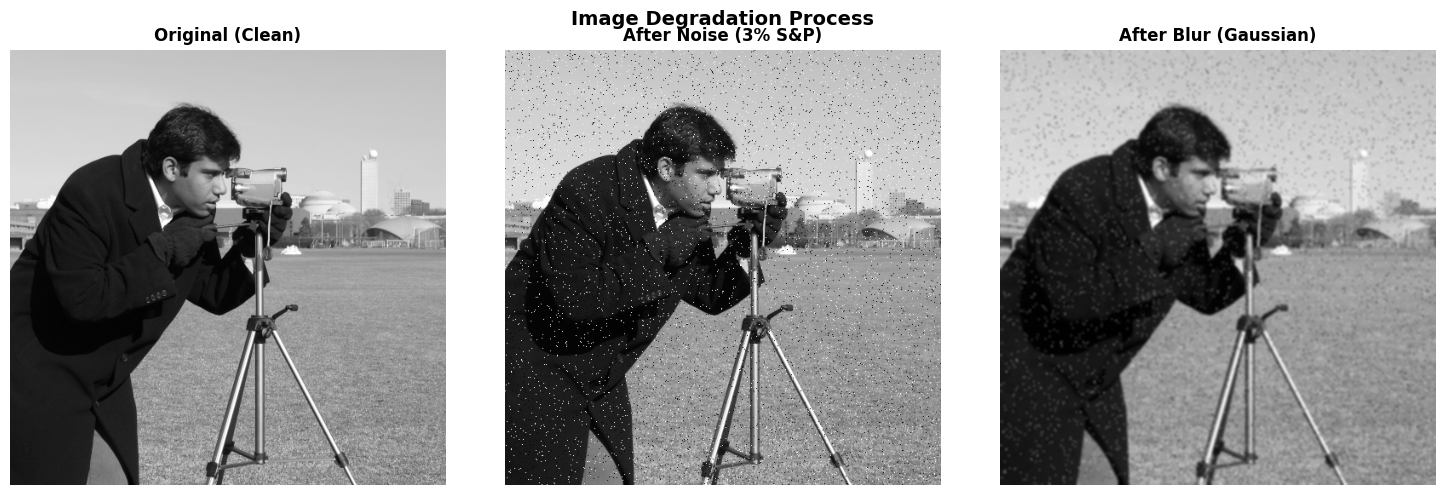

In [ ]:
# Load original image
original_ex3 = data.camera()

# Step 1: Add noise (sensor noise)
np.random.seed(42)
noisy_ex3 = add_salt_pepper(original_ex3, noise_level=0.03)

# Step 2: Add blur (camera shake)
degraded = cv2.GaussianBlur(noisy_ex3, (5, 5), sigmaX=1.5)

print('**** DEGRADATION PIPELINE ****')
print('Step 1: Add noise (3% salt-and-pepper)')
print('Step 2: Add blur (Gaussian 5x5, sigma=1.5)')
print(f'Degraded image range: [{degraded.min()}, {degraded.max()}]')

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Image Degradation Process', fontsize=14, fontweight='bold')

axes[0].imshow(original_ex3, cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(noisy_ex3, cmap='gray')
axes[1].set_title('After Noise', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(degraded, cmap='gray')
axes[2].set_title('After Blur (Gaussian)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Step 2: CORRECT Restoration Pipeline - Denoise THEN Sharpen

In [ ]:
print('**** RESTORATION PIPELINE ****')
print('CORRECT ORDER: Denoise → Sharpen')

# Stage 1: Denoise
denoised = cv2.medianBlur(degraded, ksize=3)
print('Applied: Median filter to remove noise')

# Stage 2: Sharpen
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

laplacian = cv2.filter2D(denoised.astype(np.float32), -1, kernel)
restored = np.clip(denoised.astype(np.float32) + laplacian, 0, 255).astype(np.uint8)
print('Applied: Laplacian filter to sharpen')
print('Restoration complete!')

**** RESTORATION PIPELINE ****
CORRECT ORDER: Denoise → Sharpen
Applied: Median filter to remove noise
Applied: Laplacian filter to sharpen
Restoration complete!


### Step 3: WRONG Order - Sharpen THEN Denoise

In [ ]:
print('**** WRONG ORDER (for comparison) ****')
print('WRONG ORDER: Sharpen → Denoise')

# WRONG: Sharpen first
laplacian_wrong = cv2.filter2D(degraded.astype(np.float32), -1, kernel)
sharpened_first = np.clip(degraded.astype(np.float32) + laplacian_wrong, 0, 255).astype(np.uint8)

# WRONG: Then denoise
wrong_result = cv2.medianBlur(sharpened_first, ksize=3)

print('Problem: Noise is amplified before denoising!')
print('Result: Damaged sharp features')

**** WRONG ORDER (for comparison) ****
WRONG ORDER: Sharpen → Denoise
Problem: Noise is amplified before denoising!
Result: Damaged sharp features


### Step 4: Compare Both Approaches

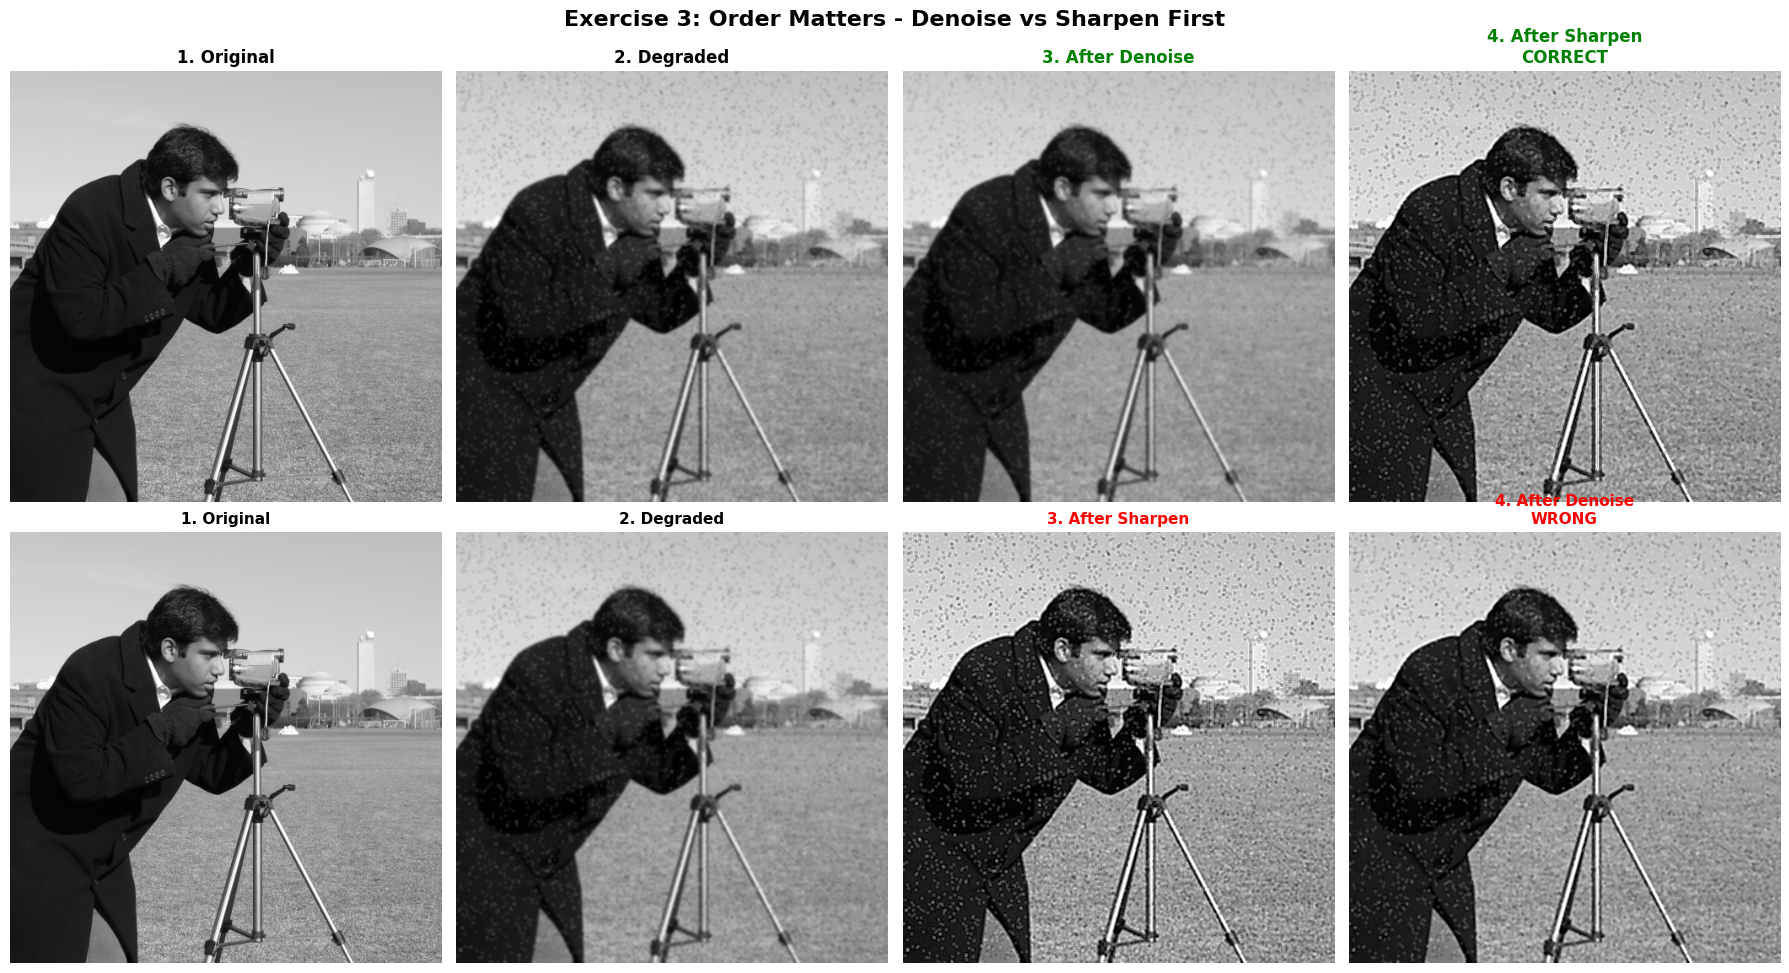

Figure saved as image_output_exercise3.png


In [ ]:
# Create comparison figure
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Exercise 3: Order Matters - Denoise vs Sharpen First',
             fontsize=16, fontweight='bold')

# Row 1: CORRECT order
axes[0, 0].imshow(original_ex3, cmap='gray')
axes[0, 0].set_title('1. Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(degraded, cmap='gray')
axes[0, 1].set_title('2. Degraded', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(denoised, cmap='gray')
axes[0, 2].set_title('3. After Denoise', fontsize=12, fontweight='bold', color='green')
axes[0, 2].axis('off')

axes[0, 3].imshow(restored, cmap='gray')
axes[0, 3].set_title('4. After Sharpen\nCORRECT', fontsize=12, fontweight='bold', color='green')
axes[0, 3].axis('off')

# Row 2: WRONG order
axes[1, 0].imshow(original_ex3, cmap='gray')
axes[1, 0].set_title('1. Original', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(degraded, cmap='gray')
axes[1, 1].set_title('2. Degraded', fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(sharpened_first, cmap='gray')
axes[1, 2].set_title('3. After Sharpen', fontsize=11, fontweight='bold', color='red')
axes[1, 2].axis('off')

axes[1, 3].imshow(wrong_result, cmap='gray')
axes[1, 3].set_title('4. After Denoise\nWRONG', fontsize=11, fontweight='bold', color='red')
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('image_output_exercise3.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure saved as image_output_exercise3.png')

---
# EXERCISE 4: Unsharp Masking (Extension)

### Step 1: Implement Unsharp Masking Function

In [ ]:
def unsharp_mask(image, sigma=2.0, k=1.5):
    """Apply unsharp masking: sharpened = original + k * (original - blur)."""
    # Step 1: Create blurred version
    blurred = cv2.GaussianBlur(image.astype(np.float32), (0, 0), sigmaX=sigma)

    # Step 2: Compute high-frequency content (edges)
    mask = image.astype(np.float32) - blurred

    # Step 3: Add k times the mask back
    sharpened = image.astype(np.float32) + k * mask

    # Step 4: Clip and return
    return np.clip(sharpened, 0, 255).astype(np.uint8)

original_ex4 = data.camera()

print('=== UNSHARP MASKING ===')
print('Formula: sharpened = original + k * (original - blur)')
print(f'Image shape: {original_ex4.shape}')

=== UNSHARP MASKING ===
Formula: sharpened = original + k * (original - blur)
Image shape: (512, 512)


### Step 2: Test Different Sharpening Strengths (k values)


=== TESTING DIFFERENT SHARPENING STRENGTHS ===
k = 0.5: Created
k = 1.0: Created
k = 1.5: Created
k = 2.0: Created
k = 3.0: Created


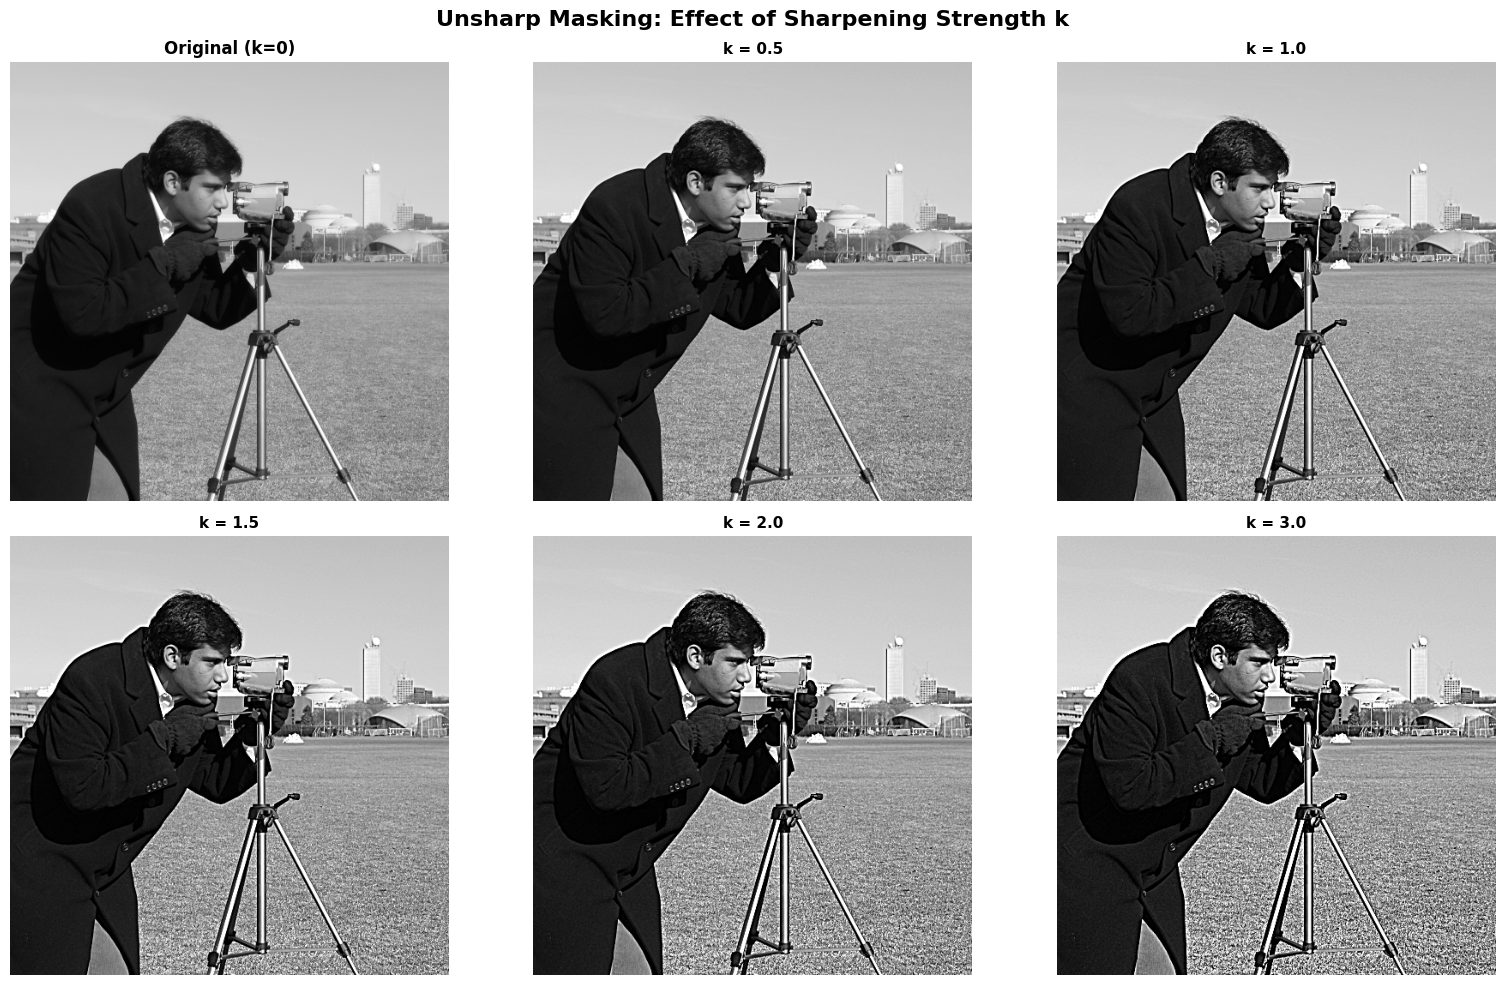


 Figure saved as image_output_exercise4.png


In [ ]:
# Test different k values
k_values = [0.5, 1.0, 1.5, 2.0, 3.0]

print('\n=== TESTING DIFFERENT SHARPENING STRENGTHS ===')

results = []
for k in k_values:
    result = unsharp_mask(original_ex4, sigma=2.0, k=k)
    results.append(result)
    print(f'k = {k}: Created')

# Create comparison figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Unsharp Masking: Effect of Sharpening Strength k',
             fontsize=16, fontweight='bold')

# Original
axes[0, 0].imshow(original_ex4, cmap='gray')
axes[0, 0].set_title('Original (k=0)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Sharpened versions
for idx, (img, k) in enumerate(zip(results, k_values)):
    row = (idx + 1) // 3
    col = (idx + 1) % 3

    axes[row, col].imshow(img, cmap='gray')
    title = f'k = {k}'
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('image_output_exercise4.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Figure saved as image_output_exercise4.png')

### Step 3: Plot Sharpness Score vs k


=== SHARPNESS SCORES ===
Original image:  1133.2
----------------------------------------
k = 0.5:  2509.5 (+121.5%)
k = 1.0:  4291.3 (+278.7%)
k = 1.5:  6358.6 (+461.1%)
k = 2.0:  8630.2 (+661.6%)
k = 3.0: 13408.4 (+1083.3%)


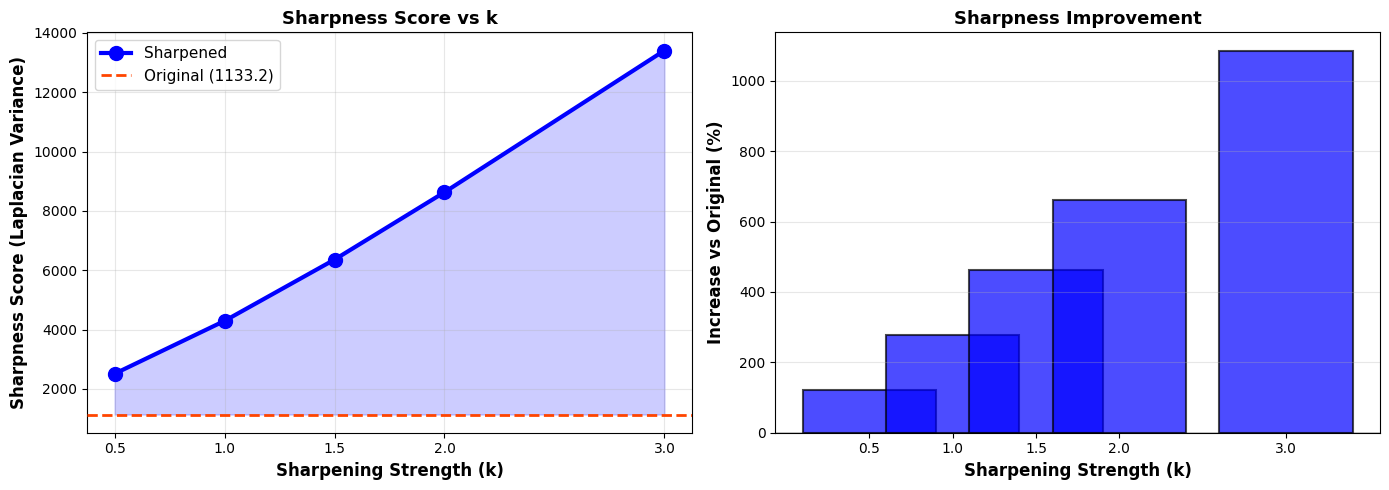


 Plot saved as exercise4_sharpness_image_plot.png


In [ ]:
# Define sharpness scoring function
lap_kernel = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]], dtype=np.float32)

def sharpness_score(image):
    """Compute sharpness using Laplacian variance."""
    lap = cv2.filter2D(image.astype(np.float32), -1, lap_kernel)
    return lap.var()

# Compute scores
scores = [sharpness_score(img) for img in results]
original_score = sharpness_score(original_ex4)

print('\n=== SHARPNESS SCORES ===')
print(f'Original image: {original_score:7.1f}')
print('-' * 40)

for k, score in zip(k_values, scores):
    pct_increase = (score / original_score - 1) * 100
    print(f'k = {k:3.1f}: {score:7.1f} ({pct_increase:+.1f}%)')

# Create plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
ax1.plot(k_values, scores, 'bo-', linewidth=3, markersize=10, label='Sharpened', zorder=5)
ax1.axhline(y=original_score, color='orangered', linestyle='--', linewidth=2,
            label=f'Original ({original_score:.1f})', zorder=3)
ax1.fill_between(k_values, original_score, scores, alpha=0.2, color='blue')
ax1.set_xlabel('Sharpening Strength (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sharpness Score (Laplacian Variance)', fontsize=12, fontweight='bold')
ax1.set_title('Sharpness Score vs k', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_values)

# Plot 2
pct_increases = [(s / original_score - 1) * 100 for s in scores]
colors = ['blue' if pct > 0 else 'red' for pct in pct_increases]
ax2.bar(k_values, pct_increases, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Sharpening Strength (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Increase vs Original (%)', fontsize=12, fontweight='bold')
ax2.set_title('Sharpness Improvement', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(k_values)

plt.tight_layout()
plt.savefig('exercise4_sharpness_image_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Plot saved as exercise4_sharpness_image_plot.png')